# Please install gymnasium
- This library provide a standard API, with functions like
  - step(s, a) to give the results of taking one steo from a with action a.
  - reset() to reset to the original state

In [ ]:
# import gymnasium as gym

# # 初始化环境
# env = gym.make("CartPole-v1", render_mode="human")

# # 重置环境并获取第一次的观测
# observation, info = env.reset(seed=42)

# episode_over = False
# while not episode_over:
#     # 在这里插入你自己的策略
#     action = env.action_space.sample()

#     # 执行动作使环境运行一个时间步（状态转移）
#     # 接收下一个观测，奖励，以及是否结束或者截断
#     observation, reward, terminated, truncated, info = env.step(action)

#     episode_over = terminated or truncated  # 如果回合结束，跳出循环。多回合则注释掉。

#     # 如果回合结束，重置环境以开始新的回合
#     if terminated or truncated:
#         observation, info = env.reset()

# env.close()

# Four room
- This is a classic example from a paper of Sutton
- https://people.cs.umass.edu/~barto/courses/cs687/Sutton-Precup-Singh-AIJ99.pdf

- "As a simple illustration of planning with options, consider the rooms example, a gridworld environment of four rooms as shown in Fig. 2. The cells of the grid correspond to the states of the environment. From any state the agent can perform one of four actions, up, down, left or right, which have a stochastic effect. With probability 2/3, the actions cause the agent to move one cell in the corresponding direction, and with probability 1/3, the agent moves instead in one of the other three directions, each with probability 1/9. In either case, if the movement would take the agent into a wall then the agent remains in the same cell. For now we consider a case in which rewards are zero on all state transitions"

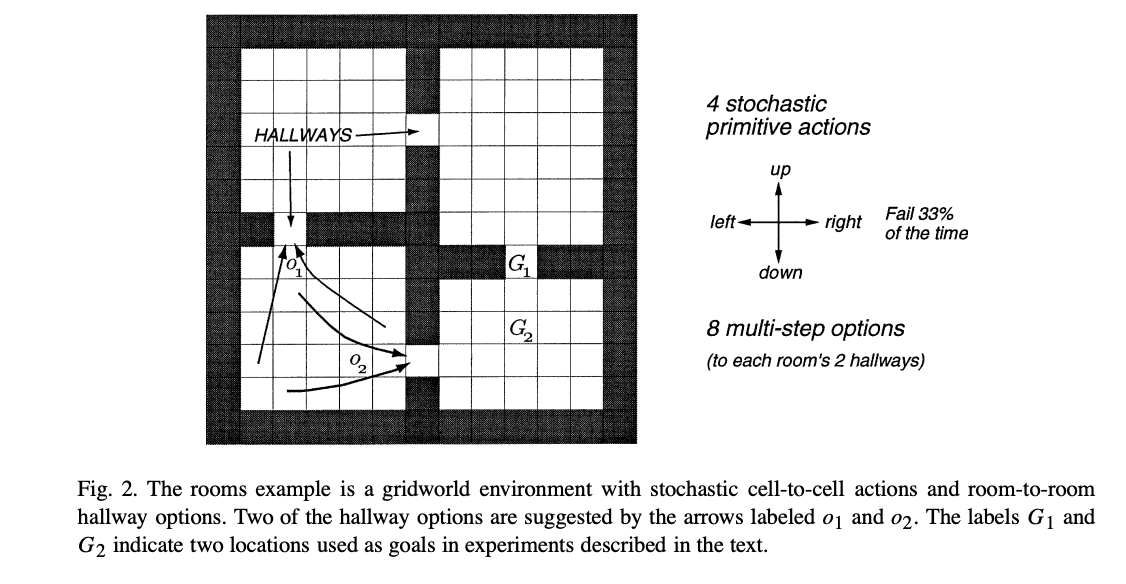

# 1: Complete the Implementation of the Four Rooms environment 

- Please complete the implementation in the step function. You are to implement this "Slippage", "With probability 2/3, the actions cause the agent to move one cell in the corresponding direction, and with probability 1/3, the agent moves instead in one of the other three directions, each with probability 1/9."
- But use self.slippage in place of 1/3: with probability (1-self.slippage), the actions cause the agent to move one cell in the corresponding direction, and with probability self.slippage/3, the agent moves instead in one of the other three directions.
- So if self.slippage = 1/3, that gives the Sutton's description

In [4]:

import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
class FourRoomEnv(gym.Env):
    """
    Classic four-room gridworld.
    Grid: 11x11, rooms separated by walls with doorways.
    State: (row, col) position of the agent
    Action: 0=up, 1=right, 2=down, 3=left
    Reward: 0 per step, +10 at goal
    slippage: a scaler. If slippage != 0, with probability 1-slippage, it performs the action specified, 
    .         and with slippage/3, takes one of the other 3 actions
    """
    metadata = {"render_modes": ["ansi"], "render_fps": 2}

    def __init__(self, render_mode=None, slippage = 0):
        super().__init__()
        self.grid_size = 13
        self.action_space = gym.spaces.Discrete(4)# {0, 1, 2, 3}
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size])
        self.agent_pos = [1, 1]
        self.goal_pos = [11, 11]
        self.render_mode = render_mode
        self.slippage = slippage

        # Walls: 1 = wall, 0 = empty
        self.walls = np.zeros((self.grid_size, self.grid_size), dtype=int)
        self._build_walls()

    def _build_walls(self):
        # Add outer walls
        self.walls[0, :] = 1
        self.walls[-1, :] = 1
        self.walls[:, 0] = 1
        self.walls[:, -1] = 1

        # Add inner walls to make four rooms
        self.walls[:, 6] = 1
        self.walls[6, 1:6] = 1
        self.walls[7, 6:13] = 1
        

        # Doors (openings in walls)
        self.walls[2, 6] = 0
        self.walls[10, 6] = 0
        self.walls[6, 2] = 0
        self.walls[7, 9] = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = [1, 1]
        return np.array(self.agent_pos), {}

    def step(self, action):
        moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
        change = np.random.random() < self.slippage
        if change:
            other_actions = [a for a in moves if a != action]
            action = np.random.choice(other_actions)


        # Implement code here to redefine 'action':
        # "With probability 2/3, the actions cause the agent to move one cell in the 
        # corresponding direction, and with probability 1/3, the agent moves instead in 
        # one of the other three directions, each with probability 1/9."
        # But use self.slippage in place of 1/3
        # Your code here  ****************** 

        delta = moves[action]

        new_pos = [self.agent_pos[0] + delta[0], self.agent_pos[1] + delta[1]]

        # Check collision with walls
        if self.walls[new_pos[0], new_pos[1]] == 0:
            self.agent_pos = new_pos

        reward = 10 if self.agent_pos == self.goal_pos else 0
        done = self.agent_pos == self.goal_pos
        return np.array(self.agent_pos), reward, done, False, {}

    def render(self):
        if self.render_mode != "ansi":
            return
        grid = np.where(self.walls == 1, "#", ".")
        grid[tuple(self.agent_pos)] = "A"
        grid[tuple(self.goal_pos)] = "G"
        print("\n".join("".join(row) for row in grid))
        print()


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_runs(res_list):
    """
    Plots individual trials and their mean cumulative reward over time.
    res_list : list of lists or 2D array. Each inner list contains rewards over time for a single trial.
    """
    res_array = np.array(res_list)
    n_steps = res_array.shape[1]
    time = np.arange(n_steps)
    plt.figure(figsize=(8, 6))
    for trial in res_array:
        plt.plot(time, trial, linestyle="--", linewidth=1, alpha=0.7)

    mean_reward = res_array.mean(axis=0)
    plt.plot(time, mean_reward, linestyle="-", linewidth=2, color="k", label="Mean reward")
    
    plt.xlabel("Time step")
    plt.ylabel("Cumulative reward")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
# Try out the class
fr = FourRoomEnv(render_mode = 'ansi', slippage = 1/3)
fr.step(1) # move right
fr.render()

#############
#.A...#.....#
#...........#
#.....#.....#
#.....#.....#
#.....#.....#
##.####.....#
#.....###.###
#.....#.....#
#.....#.....#
#...........#
#.....#....G#
#############



# 2 Implement an experiment with a policy pi

- We implement an experiment, where you input a policy pi = [p_up, p_right, p_down, p_left], follow it for 10000 steps, reset if hit the terminal state, and get the cumulative rewards

In [7]:
import random

def experiment(pi = None, steps = 10000, runs = 10, slippage = 0):
    # do an experiment of 'runs' runs, each with 'steps' steps, and return 
    # the cumulative reward over these steps as an array of length 'runs'
    # if Pi is input as a list of 4 probabilities, they specifies the 
    # probability of UP, RIGHT, DOWN and LEFT
    if pi is None:
        pi = [0.25, 0.25, 0.25, 0.25]
    random.seed(2)
    ntrials = steps
    res = []
    fr = FourRoomEnv(render_mode = 'ansi', slippage = slippage)
    action_list = list(range(fr.action_space.n))
    for run in range(runs):
        episode_over = False
        total_reward = 0
        rewards = np.zeros(ntrials)
        for trial in range(steps):
            action = np.random.choice(action_list,p = pi)
            observation, reward, terminated, truncated, info = fr.step(action)
            episode_over = terminated or truncated
            total_reward += reward
            rewards[trial] = total_reward
            if episode_over:
                seed = random.randint(0, 2**32 - 1)
                fr.reset(seed = seed)
        res.append(rewards)
    return res

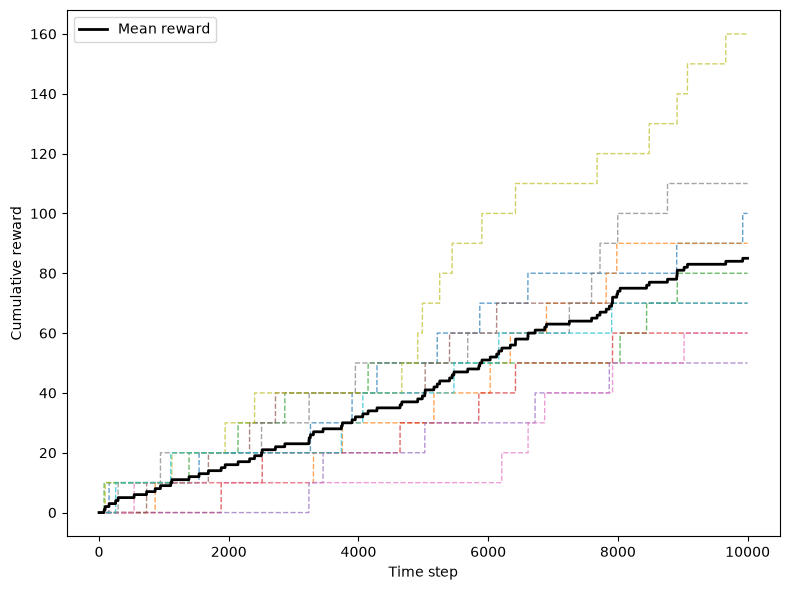

In [8]:
res_rand = experiment()
plot_runs(res_rand)

# 3 Implement two more policy, one likely better and one worse than random

In [9]:
# implement better policy. Define your better policy
pi = [0.1,0.4,0.4,0.1]
res_better = experiment(pi, steps = 10000, runs = 10)

# implement better policy, but with slippage of 0.5
res_better_with_slippage = experiment(pi,steps=10000,runs=10,slippage=0.5)# pi = None, steps = 10000, runs = 10, slippage = 0

In [10]:
# implement worse policy. Define your worse than random policy
pi = [0.25,0.25,0.2,0.3]
res_worse = experiment(pi, steps = 10000, runs = 10)

In [11]:
# self impliment a worst version
pi = [0.3,0.2,0.2,0.3]
res_worst = experiment(pi, steps = 10000, runs = 10)

- Code to plot multiple experiments

In [12]:
def plot_multiple_runs(res_lists, labels=None, colors=None):
    """
    Plot multiple sets of trials on the same figure.
    
    res_lists : list of lists of lists
        Each element is a 2D array/list of trials x time for one "run/input".
    labels : list of str
        Labels for each run for the legend.
    colors : list of str
        Colors for the mean lines of each run.
    """
    plt.figure(figsize=(10, 6))
    
    n_runs = len(res_lists)
    if labels is None:
        labels = [f"Run {i+1}" for i in range(n_runs)]
    if colors is None:
        colors = ["r", "g", "b", "c", "m", "y"]  # extend if more than 6

    for i, res_list in enumerate(res_lists):
        res_array = np.array(res_list)
        n_steps = res_array.shape[1]
        time = np.arange(n_steps)
        
        # Plot individual trials (lighter)
        for trial in res_array:
            plt.plot(time, trial, linestyle="--", linewidth=1, alpha=0.3, color=colors[i])
        
        # Plot mean reward (solid)
        mean_reward = res_array.mean(axis=0)
        plt.plot(time, mean_reward, linestyle="-", linewidth=2, color=colors[i], label=labels[i])
    
    plt.xlabel("Time step")
    plt.ylabel("Cumulative reward")
    plt.legend()
    plt.title("Comparison of multiple runs")
    plt.tight_layout()
    plt.show()

- You should so something qualitatively similar to the following

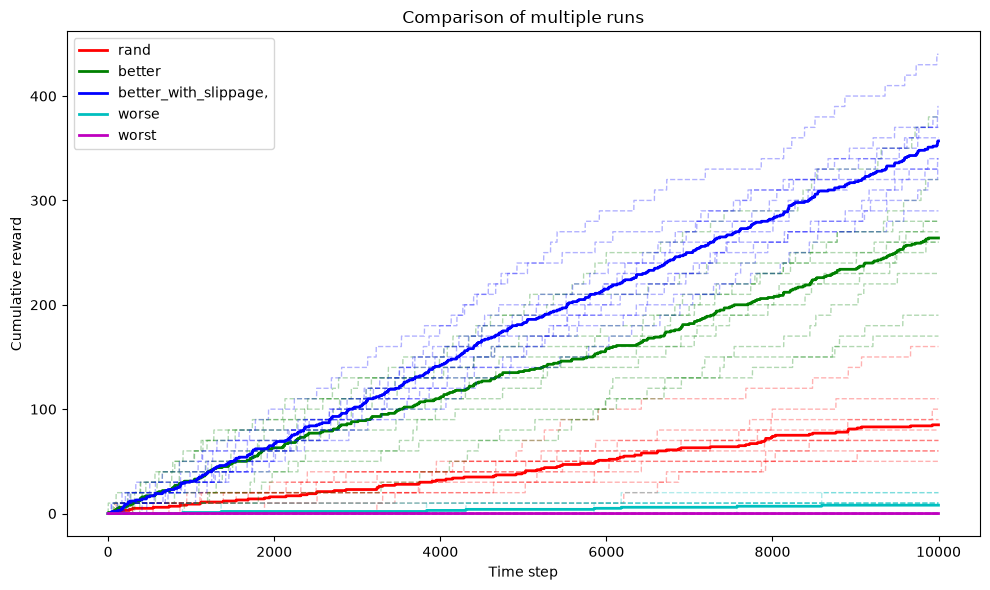

In [16]:
plot_multiple_runs([res_rand, res_better, res_better_with_slippage, res_worse,res_worst], labels = ["rand","better","better_with_slippage,", "worse","worst"])

# Problem 2: Verify the Bellman equation for state value function


This shows the state and action values for the simple grid problem in the MDP class. Write down the Bellman equation for the state value function, and verify that this equation is satisfied at state s4. **Show calculation.**

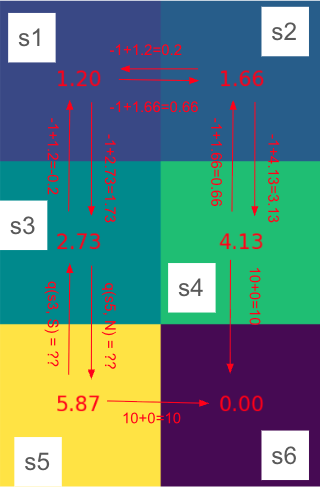



# Problem 3: Verify the Bellman equation for action value function


Bellman equation for the action value is

$$q_\pi(s, a) = \sum_{s', r} p(s', r|s, a) (r + \gamma \sum_{a'}\pi(a'|s') q_\pi(s', a'))$$

Verify that this equation is satisfied with $q_\pi(s, a) = q(s1, EAST)$, up to the 2nd decimal place. **Show calculation.**

# Solution:

Since I actually feel using state value function is weird in this question, I thought maybe we can use matrix to find out the results.


The Bellman equation for $q_\pi$ is

$$q_\pi(s,a) = \sum_{s',r} p(s',r\mid s,a)\Big(r+\gamma\sum_{a'}\pi(a'\mid s')\,q_\pi(s',a')\Big)$$

Since transitions are deterministic, each $(s,a)$ pair has one successor $s'=f(s,a)$, so this reduces to

$$q_\pi(s,a) = r(s,a) + \gamma\sum_{a'}\pi(a'\mid s')\,q_\pi(s',a')$$

### Matrix form

Stack every $(s,a)$ pair into one vector $\mathbf{Q}$. The equation above says each entry of $\mathbf{Q}$ is a fixed reward plus a weighted sum of *other entries of* $\mathbf{Q}$ — no $v(s)$ term appears. That is a linear system:

$$\mathbf{Q} = \mathbf{R} + \gamma M\mathbf{Q} \quad\Longrightarrow\quad (I-\gamma M)\mathbf{Q} = \mathbf{R} \quad\Longrightarrow\quad \mathbf{Q} = (I-\gamma M)^{-1}\mathbf{R}$$

where, for each row $(s,a)$:
- $\mathbf{R}[(s,a)] = r(s,a)$ — the immediate reward
- $M[(s,a),(s',a')] = \pi(a'\mid s')$ if $s'=f(s,a)$, and $0$ otherwise — this row spreads weight over every action available at whichever state $(s,a)$ lands in

### The 12 state-action pairs

| idx | $(s,a)$ | leads to | reward |
|---|---|---|---|
| 0 | $q(s_1,E)$ | $s_2$ | $-1$ |
| 1 | $q(s_1,S)$ | $s_3$ | $-1$ |
| 2 | $q(s_2,W)$ | $s_1$ | $-1$ |
| 3 | $q(s_2,S)$ | $s_4$ | $-1$ |
| 4 | $q(s_3,N)$ | $s_1$ | $-1$ |
| 5 | $q(s_3,E)$ | $s_4$ | $-1$ |
| 6 | $q(s_3,S)$ | $s_5$ | $-1$ |
| 7 | $q(s_4,N)$ | $s_2$ | $-1$ |
| 8 | $q(s_4,W)$ | $s_3$ | $-1$ |
| 9 | $q(s_4,S)$ | $s_6$ (terminal) | $+10$ |
| 10 | $q(s_5,N)$ | $s_3$ | $-1$ |
| 11 | $q(s_5,E)$ | $s_6$ (terminal) | $+10$ |

$s_6$ is terminal, so any $(s,a)$ pair landing there contributes only its reward with no continuation term (row of $M$ is all zeros).

In [14]:
### Code

import numpy as np

labels = [
    "q(s1,E)", "q(s1,S)",
    "q(s2,W)", "q(s2,S)",
    "q(s3,N)", "q(s3,E)", "q(s3,S)",
    "q(s4,N)", "q(s4,W)", "q(s4,S)",
    "q(s5,N)", "q(s5,E)",
]
target = ['s2','s3', 's1','s4', 's1','s4','s5', 's2','s3','s6', 's3','s6']
reward = np.array([-1,-1, -1,-1, -1,-1,-1, -1,-1,10, -1,10], dtype=float)

actions_at = {
    's1': [0,1], 's2': [2,3], 's3': [4,5,6],
    's4': [7,8,9], 's5': [10,11], 's6': [],
}

n = len(labels)
M = np.zeros((n, n))

for i in range(n):
    acts = actions_at[target[i]]
    if acts:
        pi = 1.0/len(acts)
        for j in acts:
            M[i, j] = pi

Q = np.linalg.solve(np.eye(n) - M, reward)
for lab, val in zip(labels, Q):
    print(f"{lab:10s} = {val:.2f}")

q(s1,E)    = 0.67
q(s1,S)    = 1.73
q(s2,W)    = 0.20
q(s2,S)    = 3.13
q(s3,N)    = 0.20
q(s3,E)    = 3.13
q(s3,S)    = 4.87
q(s4,N)    = 0.67
q(s4,W)    = 1.73
q(s4,S)    = 10.00
q(s5,N)    = 1.73
q(s5,E)    = 10.00


By the python code, q(s1,E) is 0.67.

In [15]:
! python -m jupyter nbconvert 05_MDP_hw-3.ipynb --to webpdf

[NbConvertApp] Converting notebook 05_MDP_hw-3.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 729920 bytes to 05_MDP_hw-3.pdf
